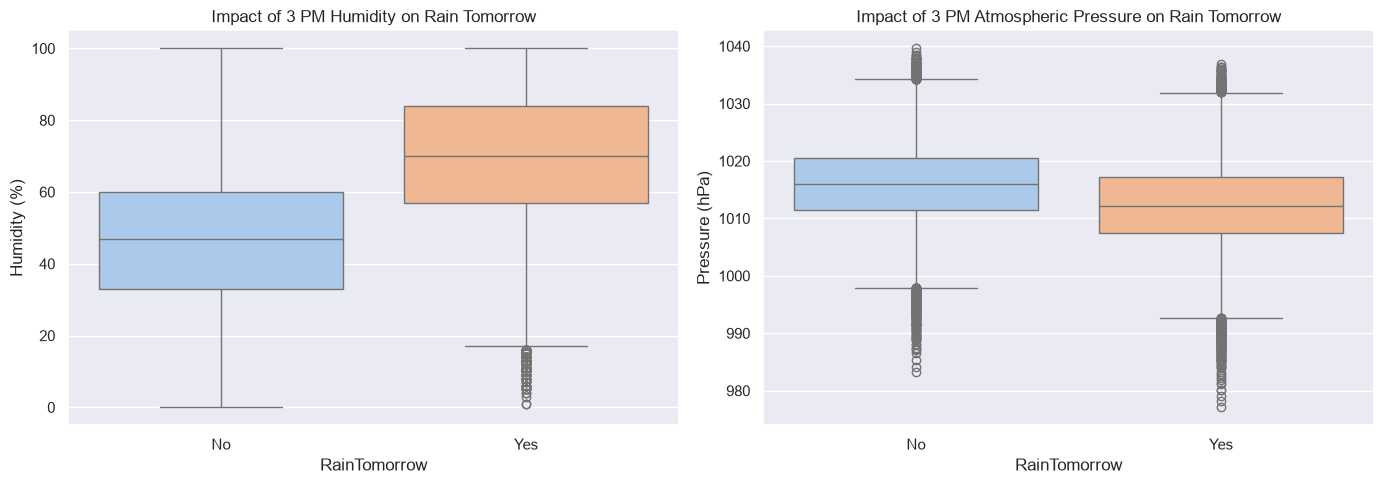

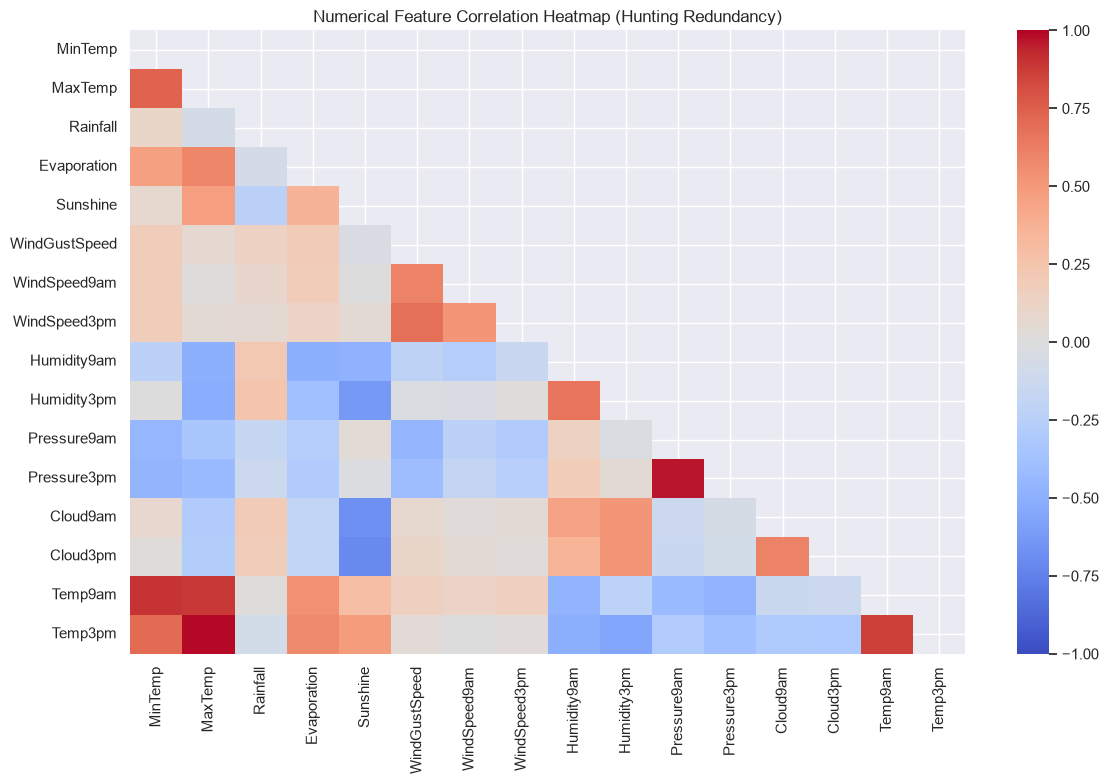

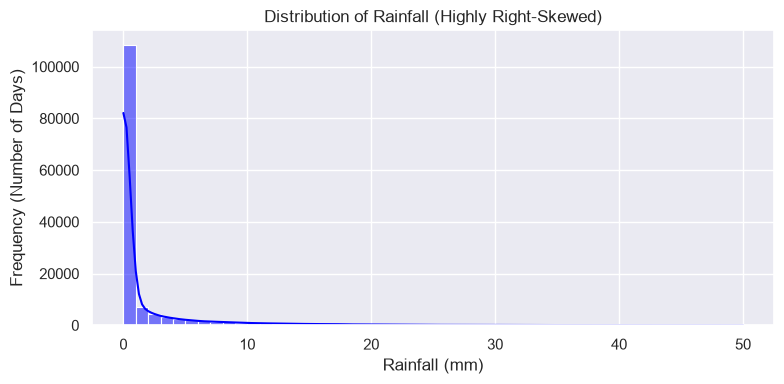

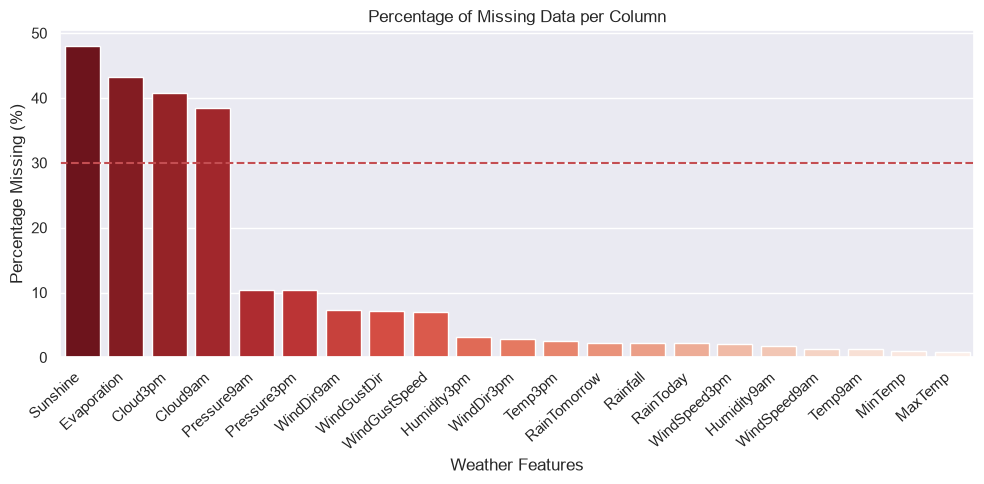

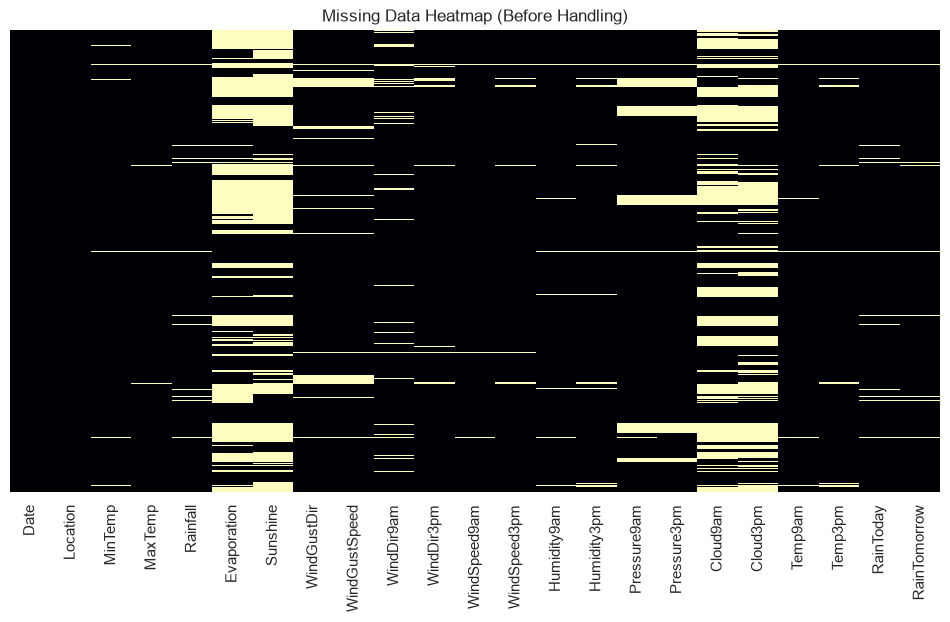

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('weatherAUS.csv')

sns.set_theme(style="darkgrid")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df, ax=axes[0], hue='RainTomorrow', palette='pastel', legend=False)
axes[0].set_title('Impact of 3 PM Humidity on Rain Tomorrow')
axes[0].set_ylabel('Humidity (%)')

sns.boxplot(x='RainTomorrow', y='Pressure3pm', data=df, ax=axes[1], hue='RainTomorrow', palette='pastel', legend=False)
axes[1].set_title('Impact of 3 PM Atmospheric Pressure on Rain Tomorrow')
axes[1].set_ylabel('Pressure (hPa)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask,cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numerical Feature Correlation Heatmap (Hunting Redundancy)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df[df['Rainfall'] <= 50]['Rainfall'], bins=50, kde=True, color='blue')
plt.title('Distribution of Rainfall (Highly Right-Skewed)')
plt.xlabel('Rainfall (mm)') # Added unit
plt.ylabel('Frequency (Number of Days)')
plt.tight_layout()
plt.show()


missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, hue=missing_pct.index, palette='Reds_r', legend=False)
plt.xticks(rotation=42, ha='right')
plt.xlabel('Weather Features')
plt.ylabel('Percentage Missing (%)')
plt.title('Percentage of Missing Data per Column')
plt.axhline(y=30, color='r', linestyle='--', label='30% Drop Threshold')


plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='magma')
plt.title('Missing Data Heatmap (Before Handling)')
plt.show()

Dropped due to >30% missing: ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

Missing values remaining: 0


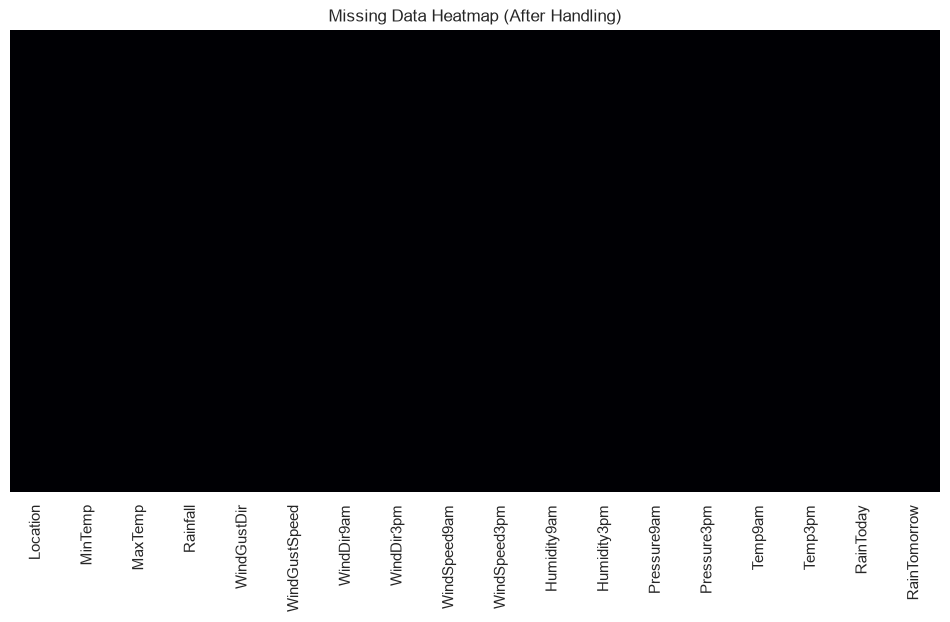

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.drop(columns=['RISK_MM', 'Date'], errors='ignore')

missing_pct = df.isnull().mean() * 100
cols_to_drop_missing = missing_pct[missing_pct > 30].index

df = df.drop(columns=cols_to_drop_missing)
print(f"Dropped due to >30% missing: {list(cols_to_drop_missing)}")

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns


for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())


for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values remaining:", df.isnull().sum().sum())

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='magma')
plt.title('Missing Data Heatmap (After Handling)')
plt.show()

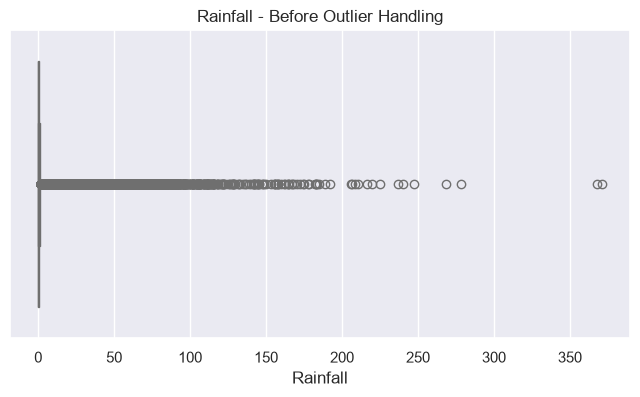


Capping outliners using the IQR (Interquartile Range) method.



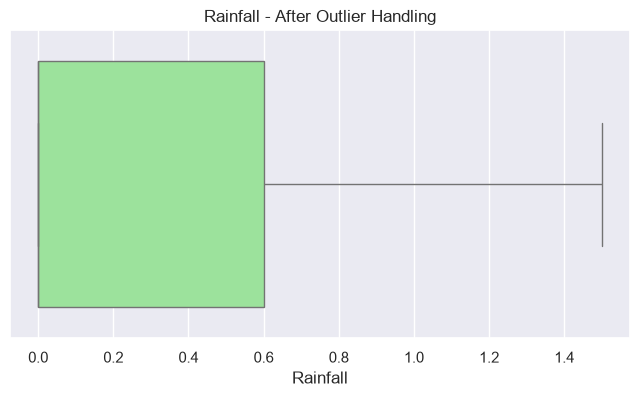

Outliers capped successfully using the IQR method.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Rainfall'], color='skyblue')
plt.title('Rainfall - Before Outlier Handling')
plt.show()

def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return series.clip(lower=lower_bound, upper=upper_bound)

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    df[col] = cap_outliers(df[col])

print("\nCapping outliners using the IQR (Interquartile Range) method.\n")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Rainfall'], color='lightgreen')
plt.title('Rainfall - After Outlier Handling')
plt.show()

print("Outliers capped successfully using the IQR method.")

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['RainToday'] = le.fit_transform(df['RainToday'].astype(str))
df['RainTomorrow'] = le.fit_transform(df['RainTomorrow'].astype(str))

nominal_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
cols_to_encode = [col for col in nominal_cols if col in df.columns]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

print("Feature encoding complete.")
print("New Dataset Shape:", df.shape)

Feature encoding complete.
New Dataset Shape: (145460, 107)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df['RainTomorrow']
X = df.drop(columns=['RainTomorrow', 'Date', 'RISK_MM'], errors='ignore')

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (116368, 106), y_train shape: (116368,)
X_test shape:  (29092, 106), y_test shape:  (29092,)


In [6]:
!python --version

Python 3.13.16
